# 02 — Enhancement methods side-by-side

Every scoring method in ConnInfPy is compared on the **same datasets** so
differences you see come from the enhancement, not data noise. Two
topologies are used, one where block-aware methods *should* win and one
where they *shouldn't*:

- **`within_module_dense`** — the effect lives entirely inside one block
  (block-aligned); `cnbs` / `ni_tfnbs` / `fbc_tfnbs` are expected to win.
- **`scattered_cross_block`** — the same number of affected edges, but
  spread thinly across every block pair (non-aligned); block-aware methods
  lose their advantage, and `tfnbs` is expected to do best.

Methods compared:

| Method | Needs `net_labels`? | What it does |
|---|---|---|
| `tstat` | no | raw t-statistic (no enhancement) |
| `nbs` | no | classical NBS (fixed threshold) |
| `tfnbs` | no | threshold-free cluster enhancement |
| `cnbs` | **yes** | aggregate within predefined blocks |
| `ni_tfnbs` | **yes** | TFNBS weighted by block density |
| `fbc_tfnbs` | **yes** | TFNBS clustered within blocks |

Runtime target: ~2 min.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from conninfpy import (
    TopologyDatasetGenerator,
    compute_p_val,
    fisher_r_to_z,
)

## 1. Shared datasets — two topologies, same effect size

Both datasets use the same nodes, modules, sample size, and effect size.
Only the spatial layout of the affected edges changes.

In [2]:
# Low SNR regime so method differences are visible. At effect_size >= 0.3
# every method finds everything and the grid is uninformative.
N, n_modules, n_sub, effect_size = 40, 4, 18, 0.2
topologies = ["within_module_dense", "scattered_cross_block"]

gen = TopologyDatasetGenerator(n_nodes=N, n_modules=n_modules, seed=1)
datasets = {
    name: gen.generate(name, effect_size=effect_size,
                       n_samples=n_sub, time_points=80)
    for name in topologies
}
fz = {name: (fisher_r_to_z(ds.group1), fisher_r_to_z(ds.group2))
      for name, ds in datasets.items()}

labels = datasets[topologies[0]].net_labels  # same label vector for both
iu = np.triu_indices(N, k=1)
gt = {name: datasets[name].effect_mask > 0 for name in topologies}

for name in topologies:
    print(f"{name:>24s}: {int(gt[name][iu].sum())} affected edges")

     within_module_dense: 45 affected edges
   scattered_cross_block: 60 affected edges


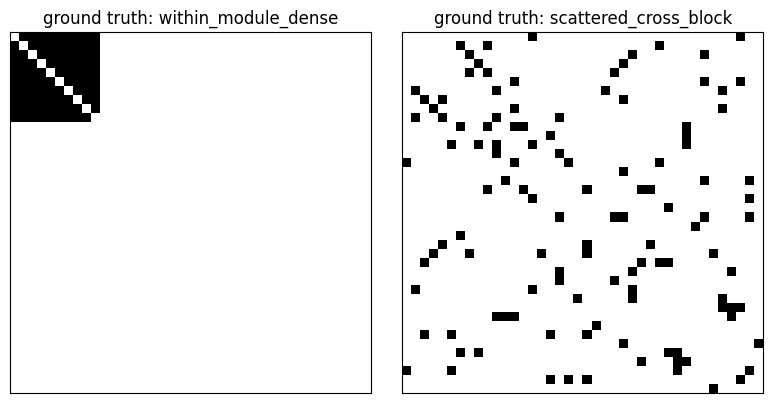

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, name in zip(axes, topologies):
    ax.imshow(gt[name], cmap="Greys")
    ax.set_title(f"ground truth: {name}")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 2. Run each method on each topology

Same permutation seed + same method kwargs — only the input data changes.

In [4]:
common = dict(
    test_type="two-sample",
    n_permutations=300,
    random_state=0,
    use_mp=False,
)
methods = {
    "tstat":     dict(method="tstat"),
    "nbs@2.3":   dict(method="nbs", threshold=2.3),
    "tfnbs":     dict(method="tfnbs"),
    "cnbs":      dict(method="cnbs", net_labels=labels),
    "ni_tfnbs":  dict(method="ni_tfnbs", net_labels=labels),
    "fbc_tfnbs": dict(method="fbc_tfnbs", net_labels=labels),
}

results = {name: {} for name in topologies}
for topo in topologies:
    g1, g2 = fz[topo]
    for m_name, m_kwargs in methods.items():
        results[topo][m_name] = compute_p_val(g1, g2, **common, **m_kwargs)
        print(f"  {topo:>24s} / {m_name:>10s} done")

       within_module_dense /      tstat done
       within_module_dense /    nbs@2.3 done


       within_module_dense /      tfnbs done
       within_module_dense /       cnbs done
       within_module_dense /   ni_tfnbs done


       within_module_dense /  fbc_tfnbs done
     scattered_cross_block /      tstat done
     scattered_cross_block /    nbs@2.3 done


     scattered_cross_block /      tfnbs done
     scattered_cross_block /       cnbs done
     scattered_cross_block /   ni_tfnbs done


     scattered_cross_block /  fbc_tfnbs done


## 3. Detection grid at $p < 0.05$

Rows = topology, columns = method. Each title reports TPR (power) and
the number of false-positive edges. The two rows should tell opposite
stories.

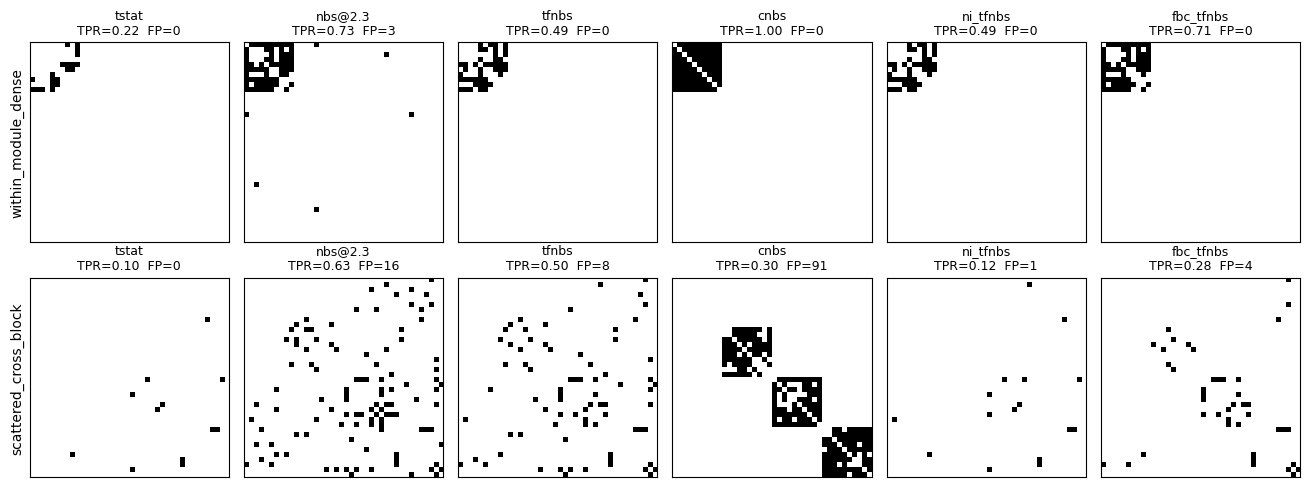

In [5]:
alpha = 0.05
n_methods = len(methods)
fig, axes = plt.subplots(len(topologies), n_methods,
                          figsize=(2.2 * n_methods, 2.5 * len(topologies)))

for row, topo in enumerate(topologies):
    for col, (m_name, p) in enumerate(results[topo].items()):
        sig = p['g2>g1'] < alpha
        tp = int((sig[iu] & gt[topo][iu]).sum())
        fp = int((sig[iu] & ~gt[topo][iu]).sum())
        fn = int((~sig[iu] & gt[topo][iu]).sum())
        tpr = tp / max(tp + fn, 1)
        ax = axes[row, col]
        ax.imshow(sig, cmap="Greys")
        ax.set_title(f"{m_name}\nTPR={tpr:.2f}  FP={fp}", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
    axes[row, 0].set_ylabel(topo, fontsize=10)
plt.tight_layout(); plt.show()

## Discussion

- **tstat** has no cluster enhancement, so it only catches the
  strongest individual edges — low power on both topologies.
- **nbs** depends strongly on the initial threshold; try 2.0 vs 3.0
  and watch how detection changes.
- **tfnbs** integrates cluster support over thresholds — usually
  the most general-purpose choice. On `scattered_cross_block` it is
  typically the only enhancement method that still has signal.
- **cnbs / ni_tfnbs / fbc_tfnbs** need a node-to-block partition
  (`net_labels`). They dominate on `within_module_dense` where the
  effect is block-aligned, but lose power on `scattered_cross_block`
  where the effect crosses every block pair.

**Takeaway**: pick the enhancement to match the *expected spatial
structure* of the effect. If you don't have a strong prior, `tfnbs`
is the safest default.